# Group-level AIRB/FIRB exposure classification by asset class

**Reference date:** 31 December 2025 (2025-Q4)  
**Population:** 77 current, accepted highest-EEA banking groups in the EBA Pillar 3 Data Hub  
**Output grain:** one LEI × asset-class cell

## Classification rules

Both FIRB and AIRB use the institution's own probability-of-default (**PD**) estimates. The CR6
wording distinguishes the treatment of loss given default (**LGD**) and conversion factors:

- **FIRB:** own PD; prescribed LGD and regulatory conversion factors.
- **AIRB:** own PD plus permitted own LGD and conversion-factor estimates.

The notebook classifies reported current exposure use, not unused permissions or individual rating
systems.

| Classification | Exact rule applied to the bank and asset class |
|---|---|
| **AIRB exposure** | Positive CR6 subtotal EAD is reported in a “with own estimates of LGD and/or conversion factors” member. Retail IRB reported only in CR6-A is also AIRB because retail IRB requires own LGD estimates. |
| **FIRB exposure** | Positive CR6 subtotal EAD is reported in a “without own estimates of LGD or conversion factors” member. Institutions IRB reported only in CR6-A is also FIRB under the CRR3 prescribed-LGD treatment. |
| **Mixed AIRB/FIRB exposure** | Both AIRB and FIRB CR6 subtotal EAD are positive. |
| **Supervisory slotting exposure** | Specialised-lending IRB is reported in the CR6-A slotting row and no AIRB/FIRB CR6 subtotal is present. |
| **IRB treatment - AIRB/FIRB not applicable** | Current IRB treatment is reported for CIU or other non-credit-obligation assets, for which the AIRB/FIRB own-LGD/CCF distinction is not the applicable classification. |
| **DQ exception - CR6-A IRB does not reconcile to CR6** | CR6-A reports current non-retail, non-slotting IRB exposure for a class that should have an AIRB/FIRB CR6 subtotal, but no such subtotal is available. |
| **No current IRB exposure** | CR6-A reports positive class EAD and no positive current-IRB value in column `0040`. |
| **No IRB exposure - SA under CRR3** | Applied to equity as the current CRR3 treatment. |
| **Not reported / not applicable** | No usable class-level CR6-A or CR6 value is present. |


## 1. Data actually used

The analysis uses two 2025-Q4 EBA Pillar 3 Data Hub templates plus the entity, report-instance and
open-table metadata needed to identify the reporting group and interpret each fact.

| Hub data | Exact coordinates and retained fields | Use in this notebook |
|---|---|---|
| **EU CR6-A** (`K_26.01`, Hub `TableVID 6261`) | Asset-class rows `0010`–`0150`; total row `0160`; column `0020` total regulatory EAD; column `0040` current IRB share | Row `0160`, column `0020` defines banks with positive total EAD. At class level, `0020` establishes whether exposure exists and `0040` is used only as a positive/non-positive current-IRB signal. The numerical percentage is not used in the classification or chart. Specialised-lending rows `0060` and `0070` distinguish non-slotting and slotting exposure. |
| **EU CR6** (`K_26.00.a`, Hub `TableVID 6295`) | Subtotal row `0180`; EAD column `0040`; `UniqueKeyID`; the open member “Exposure class by approach for prudential purposes” | The member maps each positive subtotal EAD to an asset class and to use or non-use of own LGD/CCF estimates. “With own estimates” is AIRB; “without own estimates” is FIRB. Both use own PD estimates. These EAD amounts determine mixed exposure and AIRB/FIRB dominance. |
| **Entity metadata** | LEI, bank name, country, `InstitutionType`, `IS_HIG_LEV_EEA`, entity key | LEI is the bank identifier. The population includes only `Large highest EEA` and `Other highest EEA` records with `IS_HIG_LEV_EEA = YES`. |
| **Report-instance metadata** | `InstanceID`, `ReferenceDate`, `IsCurrent`, `IsAccepted`, `Status`, source-report link | Facts must be dated `2025-12-31`, current, accepted and have status `Accepted`. Source links are retained in the detailed evidence table. |
| **Open-table metadata** | `UniqueKeyID`, `SheetKey1` descriptor | Resolves the CR6 exposure-class/approach member. One documented missing Hub link is repaired explicitly from the institution source report. |

The 77-bank denominator is the set of distinct LEIs with positive CR6-A total EAD after the exact
date, submission-status and highest-EEA filters above. CR6 amounts are compared only within the
same bank and asset class; they are never summed across banks.

Reference: [`pillar3_hub_data_model_reference_20260730T224432.md`](./pillar3_hub_data_model_reference_20260730T224432.md).


In [1]:
# 2. Environment and reproducibility metadata
from pathlib import Path
import json
import time
import uuid

import duckdb
import pandas as pd
import requests
from IPython.display import display

pd.set_option("display.max_columns", 80)
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 260)

REFERENCE_DATE = pd.Timestamp("2025-12-31")
EXTRACTED_AT_UTC = pd.Timestamp.now(tz="UTC")
VERSION_STAMP = "20260731"

P3DH_URL = "https://edap-public.eba.europa.eu/Report/index/MTE1?rhversion=20260722160254-2"
P3DH_REPORT = "f0de0c7c-c532-4b55-9bef-da99423cf672"
P3DH_DB = "d9c4b646-c0e6-4b73-887f-8f6702855ae2"
P3DH_MODEL = 5131315
P3DH_QUERY = (
    "https://wabi-west-europe-d-primary-redirect.analysis.windows.net"
    "/explore/querydata?synchronous=true"
)
USER_AGENT = (
    "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
    "AppleWebKit/537.36 Chrome/127.0 Safari/537.36"
)

CR6_TEMPLATE = "K_26.00"
CR6_TABLE_VID = 6295
CR6_SUBTOTAL_ROW = "0180"
CR6_EAD_COLUMN = "0040"

CR6A_TEMPLATE = "K_26.01"
CR6A_TABLE_VID = 6261

OUTPUT_DIR = Path("outputs") / "20260731_pillar3_group_irb_models"
print(f"Reference date: {REFERENCE_DATE.date()}")
print(f"Extraction started: {EXTRACTED_AT_UTC.isoformat()}")
print(f"DuckDB version: {duckdb.__version__}")

Reference date: 2025-12-31
Extraction started: 2026-08-01T06:39:12.180414+00:00
DuckDB version: 1.5.1


## 3. Read-only Hub extraction

The connector retrieves raw identifiers, report-instance attributes, table coordinates, open keys
and reported values from the public EBA semantic model. All population filters, mappings,
aggregations and classifications are executed in DuckDB SQL below.


In [2]:
# 3.1 Decode the EBA public Power BI semantic-query response
def get_public_embed_token(attempts=6, pause_seconds=5.0):
    """Return the temporary public token embedded in the EBA report page."""
    last_error = None
    for _ in range(attempts):
        try:
            session = requests.Session()
            session.headers["User-Agent"] = USER_AGENT
            response = session.get(P3DH_URL, allow_redirects=True, timeout=120)
            response.raise_for_status()
            html = response.text
            token_start = html.find("H4sI")
            if token_start >= 0:
                return html[token_start:html.index('"', token_start)]
            last_error = f"report page contained no token ({len(html):,} bytes)"
        except Exception as exc:
            last_error = repr(exc)
        time.sleep(pause_seconds)
    raise RuntimeError(f"Unable to obtain the public EBA embed token: {last_error}")


def select_column(alias, property_name):
    return {
        "Column": {
            "Expression": {"SourceRef": {"Source": alias}},
            "Property": property_name,
        },
        "Name": f"{alias}.{property_name}",
    }


def select_measure(alias, property_name):
    return {
        "Measure": {
            "Expression": {"SourceRef": {"Source": alias}},
            "Property": property_name,
        },
        "Name": f"{alias}.{property_name}",
    }


def equals_filter(alias, property_name, literal):
    return {
        "Condition": {
            "Comparison": {
                "ComparisonKind": 0,
                "Left": {
                    "Column": {
                        "Expression": {"SourceRef": {"Source": alias}},
                        "Property": property_name,
                    }
                },
                "Right": {"Literal": {"Value": literal}},
            }
        }
    }


def decode_powerbi_rows(response_text):
    """Expand Power BI dictionary and repeat-mask encoding into ordinary rows."""
    payload = json.loads(response_text.lstrip("\ufeff"))
    shapes = payload["results"][0]["result"]["data"].get("dsr", {}).get("DataShapes")
    if shapes and "odata.error" in shapes[0]:
        raise RuntimeError(shapes[0]["odata.error"]["message"]["value"])

    decoded_rows = []
    for result in payload["results"]:
        data_set_result = result["result"]["data"].get("dsr")
        if not data_set_result:
            continue
        for data_set in data_set_result.get("DS", []):
            dictionaries = data_set.get("ValueDicts", {})
            column_specs = None
            for phase in data_set.get("PH", []):
                for encoded_rows in phase.values():
                    previous_row = []
                    for encoded in encoded_rows:
                        if "S" in encoded:
                            column_specs = encoded["S"]
                        if column_specs is None:
                            continue
                        repeat_mask = encoded.get("R", 0)
                        null_mask = encoded.get("Ø", 0)
                        decoded = []

                        def dictionary_value(value, spec):
                            name = spec.get("DN")
                            if (
                                name in dictionaries
                                and isinstance(value, int)
                                and 0 <= value < len(dictionaries[name])
                            ):
                                return dictionaries[name][value]
                            return value

                        if "C" in encoded:
                            values = encoded["C"]
                            value_index = 0
                            for position, spec in enumerate(column_specs):
                                if null_mask >> position & 1:
                                    decoded.append(None)
                                elif repeat_mask >> position & 1 or value_index >= len(values):
                                    decoded.append(
                                        previous_row[position]
                                        if position < len(previous_row)
                                        else None
                                    )
                                else:
                                    decoded.append(dictionary_value(values[value_index], spec))
                                    value_index += 1
                        else:
                            for position, spec in enumerate(column_specs):
                                key = spec.get("N", f"G{position}")
                                if key in encoded:
                                    decoded.append(dictionary_value(encoded[key], spec))
                                elif null_mask >> position & 1:
                                    decoded.append(None)
                                else:
                                    decoded.append(
                                        previous_row[position]
                                        if position < len(previous_row)
                                        else None
                                    )
                        decoded_rows.append(decoded)
                        previous_row = decoded
    return decoded_rows


def query_public_p3dh(token, sources, selections, filters, row_limit=120_000):
    """Submit one read-only semantic query to the public P3DH model."""
    semantic_query = {
        "Version": 2,
        "From": sources,
        "Select": selections,
        "Where": filters,
    }
    body = {
        "version": "1.0.0",
        "queries": [{
            "Query": {
                "Commands": [{
                    "SemanticQueryDataShapeCommand": {
                        "Query": semantic_query,
                        "Binding": {
                            "Primary": {
                                "Groupings": [{
                                    "Projections": list(range(len(selections)))
                                }]
                            },
                            "DataReduction": {
                                "DataVolume": 4,
                                "Primary": {"Window": {"Count": row_limit}},
                            },
                            "Version": 1,
                        },
                    }
                }],
                "QueryId": "",
                "ApplicationContext": {
                    "DatasetId": P3DH_DB,
                    "Sources": [{"ReportId": P3DH_REPORT, "VisualId": "v"}],
                },
            }
        }],
        "cancelQueries": [],
        "modelId": P3DH_MODEL,
    }
    headers = {
        "Authorization": f"EmbedToken {token}",
        "Content-Type": "application/json;charset=UTF-8",
        "X-PowerBI-ResourceKey": P3DH_REPORT,
        "ActivityId": str(uuid.uuid4()),
        "RequestId": str(uuid.uuid4()),
    }
    response = requests.post(P3DH_QUERY, headers=headers, json=body, timeout=300)
    response.raise_for_status()
    return decode_powerbi_rows(response.content.decode("utf-8-sig"))

In [3]:
# 3.2 Retrieve metadata and the two narrowly scoped fact sets
token = get_public_embed_token()


def load_table_rows(table_vid):
    fields = ["TableVID", "HeaderCode", "HeaderLabel", "IsKey", "Order"]
    rows = query_public_p3dh(
        token,
        [{"Name": "r", "Entity": "dm_Row", "Type": 0}],
        [select_column("r", field) for field in fields],
        [equals_filter("r", "TableVID", f"'{table_vid}'")],
        row_limit=1_000,
    )
    return pd.DataFrame(rows, columns=fields)


def load_cr6_table_keys():
    fields = ["TableVID", "UniqueKeyID", "KeyDescriptor", "SheetKey1"]
    rows = query_public_p3dh(
        token,
        [{"Name": "k", "Entity": "dm_TableKey", "Type": 0}],
        [select_column("k", field) for field in fields],
        [equals_filter("k", "TableVID", f"'{CR6_TABLE_VID}'")],
        row_limit=1_000,
    )
    return pd.DataFrame(rows, columns=fields)


COMMON_SOURCES = [
    {"Name": alias, "Entity": entity, "Type": 0}
    for alias, entity in [
        ("e", "dm_Entity"),
        ("t", "dm_Template"),
        ("i", "dm_ReportInstance"),
        ("tb", "dm_Table"),
        ("r", "dm_Row"),
        ("c", "dm_Column"),
        ("f", "fact_Value"),
        ("v", "Measure P3"),
    ]
]
COMMON_SELECTIONS = [
    select_column("e", "ENT_NAM"),
    select_column("e", "EntityCode"),
    select_column("e", "InstitutionType"),
    select_column("e", "Country"),
    select_column("e", "IS_HIG_LEV_EEA"),
    select_column("e", "EntityKey"),
    select_column("i", "InstanceID"),
    select_column("i", "ReferenceDate"),
    select_column("i", "IsCurrent"),
    select_column("i", "IsAccepted"),
    select_column("i", "Status"),
    select_column("i", "ReceptionDate"),
    select_column("i", "Report File Link"),
    select_column("tb", "TableVID"),
    select_column("tb", "TableCode"),
    select_column("r", "HeaderCode"),
    select_column("c", "HeaderCode"),
]
COMMON_COLUMNS = [
    "bank", "lei", "institution_type", "country", "is_highest_eea",
    "entity_key", "instance_id", "reference_date", "is_current",
    "is_accepted", "status", "reception_date", "source_link",
    "table_vid", "table_code", "row_code", "column_code",
]


def load_cr6a_facts():
    rows = query_public_p3dh(
        token,
        COMMON_SOURCES,
        COMMON_SELECTIONS + [select_measure("v", "FactValue")],
        [
            equals_filter("t", "TemplateCode", f"'{CR6A_TEMPLATE}'"),
            equals_filter(
                "i", "ReferenceDate",
                f"datetime'{REFERENCE_DATE:%Y-%m-%d}T00:00:00'",
            ),
            equals_filter("i", "IsCurrent", "1L"),
        ],
    )
    return pd.DataFrame(rows, columns=COMMON_COLUMNS + ["fact_value"])


def load_cr6_subtotal_ead_facts():
    # Do not filter dm_Sheet.HeaderCode: in this open table the member is stored
    # in UniqueKeyID / dm_TableKey, while fact SheetKey can be null.
    sources = COMMON_SOURCES + [{"Name": "k", "Entity": "dm_TableKey", "Type": 0}]
    selections = (
        COMMON_SELECTIONS
        + [
            select_column("f", "UniqueKeyID"),
            select_column("k", "KeyDescriptor"),
            select_column("k", "SheetKey1"),
            select_measure("v", "FactValue"),
        ]
    )
    rows = query_public_p3dh(
        token,
        sources,
        selections,
        [
            equals_filter("t", "TemplateCode", f"'{CR6_TEMPLATE}'"),
            equals_filter(
                "i", "ReferenceDate",
                f"datetime'{REFERENCE_DATE:%Y-%m-%d}T00:00:00'",
            ),
            equals_filter("i", "IsCurrent", "1L"),
            equals_filter("r", "HeaderCode", f"'{CR6_SUBTOTAL_ROW}'"),
            equals_filter("c", "HeaderCode", f"'{CR6_EAD_COLUMN}'"),
        ],
    )
    return pd.DataFrame(
        rows,
        columns=COMMON_COLUMNS + [
            "unique_key_id", "key_descriptor",
            "asset_class_by_approach", "fact_value",
        ],
    )


p3_cr6a_rows = load_table_rows(CR6A_TABLE_VID)
p3_cr6_keys = load_cr6_table_keys()
p3_cr6a_raw = load_cr6a_facts()
p3_cr6_raw = load_cr6_subtotal_ead_facts()

print(f"CR6-A row metadata: {len(p3_cr6a_rows):,}")
print(f"CR6 open-table keys: {len(p3_cr6_keys):,}")
print(f"Raw 2025-Q4 CR6-A facts: {len(p3_cr6a_raw):,}")
print(f"Raw 2025-Q4 CR6 subtotal-EAD facts: {len(p3_cr6_raw):,}")

CR6-A row metadata: 19
CR6 open-table keys: 18
Raw 2025-Q4 CR6-A facts: 5,398
Raw 2025-Q4 CR6 subtotal-EAD facts: 680


## 4. SQL transformation and classification

The SQL:

1. restores four-character row and column codes and retains the raw reported values;
2. reapplies the exact date, accepted/current, highest-EEA and physical-table filters;
3. uses only CR6-A columns `0020` and `0040`;
4. maps CR6 open members to AIRB or FIRB exposure and separates specialised-lending slotting;
5. applies the deterministic retail, institutions, CIU and other-non-credit-obligation rules; and
6. flags a DQ exception when CR6-A and CR6 should reconcile but do not.

For `UniqueKeyID 161333573377302602`, the Hub fact is not linked to `dm_TableKey`. The source
report identifies it as `eba_qAE:qx2012`, “Corporates - Other without own estimates of LGD or
conversion factors”. The SQL contains that single explicit FIRB fallback and retains the repair
note and source link.


In [4]:
# 4.1 Register raw Hub extracts; no analytical pandas transformations occur
def repair_utf8_mojibake(value):
    """Repair labels that the public model exposes as UTF-8 decoded as Latin-1."""
    if value is None or not any(marker in value for marker in ("Ã", "Â")):
        return value
    try:
        return value.encode("latin-1").decode("utf-8")
    except (UnicodeEncodeError, UnicodeDecodeError):
        return value


con = duckdb.connect()
con.create_function(
    "repair_utf8_mojibake",
    repair_utf8_mojibake,
    parameters=["VARCHAR"],
    return_type="VARCHAR",
)
con.register("p3_cr6a_rows", p3_cr6a_rows)
con.register("p3_cr6_keys", p3_cr6_keys)
con.register("p3_cr6a_raw", p3_cr6a_raw)
con.register("p3_cr6_raw", p3_cr6_raw)

SQL_TRANSFORM = r"""
CREATE OR REPLACE TABLE asset_class_map AS
SELECT * FROM (VALUES
    ( 1, 'Central governments and central banks',        '0010'),
    ( 2, 'Regional governments and local authorities',    '0020'),
    ( 3, 'Public-sector entities',                        '0030'),
    ( 4, 'Institutions',                                  '0040'),
    ( 5, 'Corporates - general',                          '0051'),
    ( 6, 'Corporates - specialised lending',              '0052'),
    ( 7, 'Corporates - purchased receivables',            '0075'),
    ( 8, 'Retail - qualifying revolving',                 '0110'),
    ( 9, 'Retail - residential real estate',              '0120'),
    (10, 'Retail - purchased receivables',                '0130'),
    (11, 'Retail - other',                                '0135'),
    (12, 'Equity',                                        '0140'),
    (13, 'Collective investment undertakings',            '0145'),
    (14, 'Other non-credit-obligation assets',             '0150')
) AS t(class_order, asset_class, cr6a_row_code);

CREATE OR REPLACE TABLE cr6_key_fallback AS
SELECT * FROM (VALUES
    (
        '161333573377302602',
        'Corporates - Other without own estimates of LGD or conversion factors',
        'eba_qAE:qx2012',
        'Hub dm_TableKey link missing; resolved from the institution source report and RF4.1 glossary'
    )
) AS t(unique_key_id, fallback_descriptor, dpm_member, repair_note);

CREATE OR REPLACE VIEW cr6a_facts AS
WITH typed AS (
    SELECT
        repair_utf8_mojibake(bank) AS bank,
        lei,
        institution_type,
        country,
        is_highest_eea,
        entity_key,
        CAST(instance_id AS VARCHAR) AS instance_id,
        CASE
            WHEN try_cast(reference_date AS BIGINT) IS NOT NULL
                THEN CAST(epoch_ms(try_cast(reference_date AS BIGINT)) AS DATE)
            ELSE try_cast(reference_date AS DATE)
        END AS reference_date,
        try_cast(is_current AS INTEGER) AS is_current,
        coalesce(try_cast(is_accepted AS BOOLEAN), false) AS is_accepted,
        status,
        source_link,
        try_cast(table_vid AS INTEGER) AS table_vid,
        table_code,
        lpad(CAST(row_code AS VARCHAR), 4, '0') AS row_code,
        lpad(CAST(column_code AS VARCHAR), 4, '0') AS column_code,
        try_cast(
            regexp_replace(CAST(fact_value AS VARCHAR), 'D$', '')
            AS DOUBLE
        ) AS reported_value,
        CAST(fact_value AS VARCHAR) AS reported_value_raw
    FROM p3_cr6a_raw
)
SELECT *
FROM typed
WHERE reference_date = DATE '2025-12-31'
  AND is_current = 1
  AND is_accepted
  AND status = 'Accepted'
  AND table_vid = 6261
  AND table_code = 'K_26.01'
  AND column_code IN ('0020', '0040')
  AND institution_type IN ('Large highest EEA', 'Other highest EEA')
  AND upper(is_highest_eea) = 'YES';

CREATE OR REPLACE VIEW cr6_facts_resolved AS
WITH key_metadata AS (
    SELECT
        CAST(UniqueKeyID AS VARCHAR) AS unique_key_id,
        max(SheetKey1) AS metadata_descriptor
    FROM p3_cr6_keys
    WHERE CAST(TableVID AS VARCHAR) = '6295'
    GROUP BY 1
),
typed AS (
    SELECT
        repair_utf8_mojibake(r.bank) AS bank,
        r.lei,
        r.institution_type,
        r.country,
        r.is_highest_eea,
        r.entity_key,
        CAST(r.instance_id AS VARCHAR) AS instance_id,
        CASE
            WHEN try_cast(r.reference_date AS BIGINT) IS NOT NULL
                THEN CAST(epoch_ms(try_cast(r.reference_date AS BIGINT)) AS DATE)
            ELSE try_cast(r.reference_date AS DATE)
        END AS reference_date,
        try_cast(r.is_current AS INTEGER) AS is_current,
        coalesce(try_cast(r.is_accepted AS BOOLEAN), false) AS is_accepted,
        r.status,
        r.source_link,
        try_cast(r.table_vid AS INTEGER) AS table_vid,
        r.table_code,
        lpad(CAST(r.row_code AS VARCHAR), 4, '0') AS row_code,
        lpad(CAST(r.column_code AS VARCHAR), 4, '0') AS column_code,
        CAST(r.unique_key_id AS VARCHAR) AS unique_key_id,
        coalesce(
            r.asset_class_by_approach,
            k.metadata_descriptor,
            f.fallback_descriptor
        ) AS approach_member,
        f.dpm_member AS fallback_dpm_member,
        f.repair_note,
        try_cast(
            regexp_replace(CAST(r.fact_value AS VARCHAR), 'D$', '')
            AS DOUBLE
        ) AS reported_ead,
        CAST(r.fact_value AS VARCHAR) AS reported_value_raw
    FROM p3_cr6_raw r
    LEFT JOIN key_metadata k
      ON CAST(r.unique_key_id AS VARCHAR) = k.unique_key_id
    LEFT JOIN cr6_key_fallback f
      ON CAST(r.unique_key_id AS VARCHAR) = f.unique_key_id
),
mapped AS (
    SELECT *,
        CASE
            WHEN lower(approach_member) LIKE '%central governments%' THEN
                'Central governments and central banks'
            WHEN lower(approach_member) LIKE '%regional governments%' THEN
                'Regional governments and local authorities'
            WHEN lower(approach_member) LIKE '%public sector entities%' THEN
                'Public-sector entities'
            WHEN lower(approach_member) LIKE '%institutions%' THEN
                'Institutions'
            WHEN lower(approach_member) LIKE '%corporates - purchased receivables%' THEN
                'Corporates - purchased receivables'
            WHEN lower(approach_member) LIKE '%corporates - specialised lending%' THEN
                'Corporates - specialised lending'
            WHEN lower(approach_member) LIKE '%corporates - other%' THEN
                'Corporates - general'
            WHEN lower(approach_member) LIKE '%retail - qualifying revolving%' THEN
                'Retail - qualifying revolving'
            WHEN lower(approach_member) LIKE '%retail exposures - secured by residential%' THEN
                'Retail - residential real estate'
            WHEN lower(approach_member) LIKE '%retail exposures - purchased receivables%' THEN
                'Retail - purchased receivables'
            WHEN lower(approach_member) LIKE '%retail exposures - other%' THEN
                'Retail - other'
            WHEN lower(approach_member) LIKE '%collective investment undertakings%' THEN
                'Collective investment undertakings'
            ELSE NULL
        END AS asset_class,
        CASE
            WHEN lower(approach_member) LIKE '%without own estimates%' THEN 'FIRB'
            WHEN lower(approach_member) LIKE '%with own estimates%' THEN 'AIRB'
            ELSE 'IRB - AIRB/FIRB not disclosed'
        END AS irb_variant
    FROM typed
)
SELECT *
FROM mapped
WHERE reference_date = DATE '2025-12-31'
  AND is_current = 1
  AND is_accepted
  AND status = 'Accepted'
  AND table_vid = 6295
  AND table_code = 'K_26.00.a'
  AND row_code = '0180'
  AND column_code = '0040'
  AND institution_type IN ('Large highest EEA', 'Other highest EEA')
  AND upper(is_highest_eea) = 'YES';

CREATE OR REPLACE TABLE bank_population AS
SELECT
    lei,
    min(bank) AS bank,
    min(country) AS country,
    min(institution_type) AS institution_type,
    min(entity_key) AS entity_key,
    min(instance_id) AS cr6a_instance_id,
    min(source_link) AS cr6a_source_link,
    max(reported_value) FILTER (
        WHERE row_code = '0160' AND column_code = '0020'
    ) AS total_ead_reported
FROM cr6a_facts
GROUP BY lei
HAVING max(reported_value) FILTER (
    WHERE row_code = '0160' AND column_code = '0020'
) > 0;

CREATE OR REPLACE VIEW cr6a_class_exposure AS
SELECT
    f.lei,
    m.class_order,
    m.asset_class,
    max(f.reported_value) FILTER (WHERE f.column_code = '0020') AS class_total_ead,
    max(f.reported_value) FILTER (
        WHERE f.column_code = '0040'
    ) AS cr6a_irb_share_reported
FROM cr6a_facts f
JOIN asset_class_map m
  ON f.row_code = m.cr6a_row_code
GROUP BY f.lei, m.class_order, m.asset_class;

CREATE OR REPLACE VIEW cr6a_specialised_signals AS
SELECT
    lei,
    max(reported_value) FILTER (
        WHERE row_code = '0060' AND column_code = '0040'
    ) AS non_slotting_irb_share_reported,
    max(reported_value) FILTER (
        WHERE row_code = '0070' AND column_code = '0040'
    ) AS slotting_irb_share_reported
FROM cr6a_facts
GROUP BY lei;

CREATE OR REPLACE VIEW cr6_class_signals AS
SELECT
    lei,
    asset_class,
    sum(CASE WHEN irb_variant = 'AIRB' AND reported_ead > 0
             THEN reported_ead ELSE 0 END) AS airb_ead,
    sum(CASE WHEN irb_variant = 'FIRB' AND reported_ead > 0
             THEN reported_ead ELSE 0 END) AS firb_ead,
    sum(CASE WHEN irb_variant = 'IRB - AIRB/FIRB not disclosed' AND reported_ead > 0
             THEN reported_ead ELSE 0 END) AS unspecified_irb_ead,
    count(*) FILTER (WHERE reported_ead > 0) AS positive_cr6_members,
    string_agg(
        DISTINCT approach_member || ' [' || unique_key_id || ']',
        '; ' ORDER BY approach_member || ' [' || unique_key_id || ']'
    ) FILTER (WHERE reported_ead > 0) AS positive_member_evidence,
    min(source_link) AS cr6_source_link,
    max(CASE WHEN repair_note IS NOT NULL THEN repair_note END) AS key_repair_note
FROM cr6_facts_resolved
WHERE asset_class IS NOT NULL
GROUP BY lei, asset_class;

CREATE OR REPLACE TABLE bank_asset_class_inference AS
WITH grid AS (
    SELECT p.*, m.class_order, m.asset_class, m.cr6a_row_code
    FROM bank_population p
    CROSS JOIN asset_class_map m
),
joined AS (
    SELECT
        g.*,
        a.class_total_ead,
        a.cr6a_irb_share_reported,
        sp.non_slotting_irb_share_reported,
        sp.slotting_irb_share_reported,
        coalesce(s.airb_ead, 0) AS airb_ead,
        coalesce(s.firb_ead, 0) AS firb_ead,
        coalesce(s.unspecified_irb_ead, 0) AS unspecified_irb_ead,
        coalesce(s.positive_cr6_members, 0) AS positive_cr6_members,
        s.positive_member_evidence,
        s.cr6_source_link,
        s.key_repair_note
    FROM grid g
    LEFT JOIN cr6a_class_exposure a
      ON g.lei = a.lei AND g.asset_class = a.asset_class
    LEFT JOIN cr6a_specialised_signals sp
      ON g.lei = sp.lei
     AND g.asset_class = 'Corporates - specialised lending'
    LEFT JOIN cr6_class_signals s
      ON g.lei = s.lei AND g.asset_class = s.asset_class
),
classified AS (
    SELECT *,
        airb_ead + firb_ead + unspecified_irb_ead AS cr6_irb_ead,
        CASE
            WHEN asset_class = 'Equity' THEN 'No IRB exposure - SA under CRR3'
            WHEN asset_class IN (
                'Collective investment undertakings',
                'Other non-credit-obligation assets'
            ) AND (
                unspecified_irb_ead > 0
                OR airb_ead > 0
                OR firb_ead > 0
                OR coalesce(cr6a_irb_share_reported, 0) > 0
            ) THEN 'IRB treatment - AIRB/FIRB not applicable'
            WHEN asset_class = 'Institutions' AND airb_ead > 0
                THEN 'DQ exception - institutions AIRB conflicts with CRR3'
            WHEN asset_class = 'Institutions' AND (
                firb_ead > 0 OR coalesce(cr6a_irb_share_reported, 0) > 0
            ) THEN 'FIRB exposure'
            WHEN asset_class LIKE 'Retail - %' AND firb_ead > 0
                THEN 'DQ exception - retail FIRB conflicts with CRR3'
            WHEN asset_class LIKE 'Retail - %' AND (
                airb_ead > 0 OR coalesce(cr6a_irb_share_reported, 0) > 0
            ) THEN 'AIRB exposure'
            WHEN asset_class = 'Corporates - specialised lending'
                 AND airb_ead > 0 AND firb_ead > 0
                THEN 'Mixed AIRB/FIRB exposure'
            WHEN asset_class = 'Corporates - specialised lending' AND airb_ead > 0
                THEN 'AIRB exposure'
            WHEN asset_class = 'Corporates - specialised lending' AND firb_ead > 0
                THEN 'FIRB exposure'
            WHEN asset_class = 'Corporates - specialised lending'
                 AND coalesce(non_slotting_irb_share_reported, 0) > 0
                THEN 'DQ exception - CR6-A IRB does not reconcile to CR6'
            WHEN asset_class = 'Corporates - specialised lending'
                 AND coalesce(slotting_irb_share_reported, 0) > 0
                THEN 'Supervisory slotting exposure'
            WHEN asset_class = 'Corporates - specialised lending'
                 AND coalesce(cr6a_irb_share_reported, 0) > 0
                THEN 'DQ exception - CR6-A IRB does not reconcile to CR6'
            WHEN airb_ead > 0 AND firb_ead > 0 THEN 'Mixed AIRB/FIRB exposure'
            WHEN airb_ead > 0 THEN 'AIRB exposure'
            WHEN firb_ead > 0 THEN 'FIRB exposure'
            WHEN unspecified_irb_ead > 0
                THEN 'DQ exception - CR6 member does not identify AIRB/FIRB'
            WHEN coalesce(cr6a_irb_share_reported, 0) > 0
                THEN 'DQ exception - CR6-A IRB does not reconcile to CR6'
            WHEN class_total_ead > 0 THEN 'No current IRB exposure'
            ELSE 'Not reported / not applicable'
        END AS classification,
        CASE
            WHEN asset_class = 'Equity' THEN 'Regulatory treatment'
            WHEN asset_class IN (
                'Collective investment undertakings',
                'Other non-credit-obligation assets'
            ) AND (
                unspecified_irb_ead > 0 OR coalesce(cr6a_irb_share_reported, 0) > 0
            ) THEN 'CR6/CR6-A IRB signal; AIRB/FIRB distinction not applicable'
            WHEN asset_class = 'Institutions'
                 AND coalesce(cr6a_irb_share_reported, 0) > 0
                 AND firb_ead = 0
                THEN 'CR6-A current IRB signal plus CRR3 prescribed-LGD rule'
            WHEN asset_class LIKE 'Retail - %'
                 AND coalesce(cr6a_irb_share_reported, 0) > 0
                 AND airb_ead = 0
                THEN 'CR6-A current IRB signal plus CRR3 own-LGD rule'
            WHEN airb_ead > 0 OR firb_ead > 0 THEN 'Direct CR6 AIRB/FIRB exposure'
            WHEN classification LIKE 'DQ exception - %' THEN 'CR6-A/CR6 reconciliation exception'
            WHEN asset_class = 'Corporates - specialised lending'
                 AND coalesce(slotting_irb_share_reported, 0) > 0
                THEN 'CR6-A supervisory-slotting signal'
            WHEN class_total_ead > 0 THEN 'CR6-A class exposure; no positive current IRB signal'
            ELSE 'No usable class-level disclosure'
        END AS evidence_basis
    FROM joined
)
SELECT *,
    CASE
        WHEN airb_ead > 0 AND firb_ead > 0
            THEN round(100.0 * airb_ead / (airb_ead + firb_ead), 1)
        WHEN airb_ead > 0 THEN 100.0
        WHEN firb_ead > 0 THEN 0.0
        ELSE NULL
    END AS airb_share_of_resolved_irb_pct,
    CASE
        WHEN asset_class = 'Equity'
            THEN 'CRR3 current treatment: equity is standardised; Article 495 legacy calculations are not reclassified as current IRB.'
        WHEN asset_class IN ('Collective investment undertakings', 'Other non-credit-obligation assets')
             AND classification = 'IRB treatment - AIRB/FIRB not applicable'
            THEN 'Current IRB treatment is reported, but this exposure class is not classified by the AIRB/FIRB own-LGD/CCF distinction.'
        WHEN classification = 'Supervisory slotting exposure'
            THEN 'CR6-A reports current IRB in the specialised-lending slotting row; EU CR6 excludes supervisory-slotting exposure.'
        WHEN classification LIKE 'DQ exception - %'
            THEN 'The reported CR6-A/CR6 evidence conflicts with the applicable template or CRR3 classification rule and requires source-filing reconciliation.'
        WHEN airb_ead > 0 AND firb_ead > 0
            THEN 'Positive CR6 subtotal EAD appears in both own-estimate and without-own-estimate members.'
        WHEN airb_ead > 0
            THEN 'Positive CR6 subtotal EAD appears only in own-LGD/CCF member(s).'
        WHEN firb_ead > 0
            THEN 'Positive CR6 subtotal EAD appears only in prescribed-LGD/CCF member(s).'
        WHEN asset_class = 'Institutions' AND coalesce(cr6a_irb_share_reported, 0) > 0
            THEN 'CR6-A reports current IRB exposure; the CRR3 prescribed-LGD rule classifies institutions IRB as FIRB.'
        WHEN asset_class LIKE 'Retail - %' AND coalesce(cr6a_irb_share_reported, 0) > 0
            THEN 'CR6-A reports current IRB exposure; the CRR3 own-LGD rule classifies retail IRB as AIRB.'
        WHEN class_total_ead > 0
            THEN 'CR6-A reports exposure in the class and no positive current-IRB value in column 0040.'
        ELSE 'No usable class-level CR6-A or CR6 evidence for this bank at the reference date.'
    END AS reasoning
FROM classified;
"""

con.execute(SQL_TRANSFORM)

In [5]:
# 4.2 Validation: grain, report instances, unresolved keys and coverage
validation = con.sql("""
WITH checks AS (
    SELECT 'group banks in positive-total CR6-A population' AS check_name,
           count(*)::VARCHAR AS value
    FROM bank_population
    UNION ALL
    SELECT 'asset classes per bank', count(*)::VARCHAR
    FROM asset_class_map
    UNION ALL
    SELECT 'final bank-class rows', count(*)::VARCHAR
    FROM bank_asset_class_inference
    UNION ALL
    SELECT 'distinct LEIs in final output', count(DISTINCT lei)::VARCHAR
    FROM bank_asset_class_inference
    UNION ALL
    SELECT 'CR6 facts with unresolved open key', count(*)::VARCHAR
    FROM cr6_facts_resolved
    WHERE approach_member IS NULL
    UNION ALL
    SELECT 'CR6 facts with mapped member but unmapped broad class', count(*)::VARCHAR
    FROM cr6_facts_resolved
    WHERE approach_member IS NOT NULL AND asset_class IS NULL
    UNION ALL
    SELECT 'LEIs with >1 accepted/current CR6-A instance', count(*)::VARCHAR
    FROM (
        SELECT lei
        FROM cr6a_facts
        GROUP BY lei
        HAVING count(DISTINCT instance_id) > 1
    )
    UNION ALL
    SELECT 'DQ exception bank-class cells', count(*)::VARCHAR
    FROM bank_asset_class_inference
    WHERE classification LIKE 'DQ exception - %'
    UNION ALL
    SELECT 'LEIs with >1 accepted/current CR6 instance', count(*)::VARCHAR
    FROM (
        SELECT lei
        FROM cr6_facts_resolved
        GROUP BY lei
        HAVING count(DISTINCT instance_id) > 1
    )
)
SELECT * FROM checks
""").df()
display(validation)

expected_rows = con.sql(
    "SELECT count(*) FROM bank_population"
).fetchone()[0] * con.sql(
    "SELECT count(*) FROM asset_class_map"
).fetchone()[0]
actual_rows = con.sql(
    "SELECT count(*) FROM bank_asset_class_inference"
).fetchone()[0]
assert actual_rows == expected_rows
assert con.sql("""
    SELECT count(*) FROM cr6_facts_resolved
    WHERE approach_member IS NULL OR asset_class IS NULL
""").fetchone()[0] == 0
assert con.sql("""
    SELECT count(*) FROM (
        SELECT lei, asset_class, count(*) AS n
        FROM bank_asset_class_inference
        GROUP BY lei, asset_class
        HAVING n <> 1
    )
""").fetchone()[0] == 0

coverage_summary = con.sql("""
SELECT
    classification,
    evidence_basis,
    count(*) AS bank_asset_class_cells,
    count(DISTINCT lei) AS banks
FROM bank_asset_class_inference
GROUP BY classification, evidence_basis
ORDER BY
    CASE
        WHEN classification = 'Mixed AIRB/FIRB exposure' THEN 1
        WHEN classification = 'AIRB exposure' THEN 2
        WHEN classification = 'FIRB exposure' THEN 3
        WHEN classification = 'Supervisory slotting exposure' THEN 4
        WHEN classification = 'IRB treatment - AIRB/FIRB not applicable' THEN 5
        WHEN classification LIKE 'DQ exception - %' THEN 6
        WHEN classification = 'No current IRB exposure' THEN 7
        WHEN classification = 'No IRB exposure - SA under CRR3' THEN 8
        ELSE 9
    END,
    classification,
    evidence_basis
""").df()
display(coverage_summary)

assert con.sql("""
    SELECT count(*) FROM bank_asset_class_inference
    WHERE classification IN (
        'IRB exposure; AIRB/FIRB not identified',
        'IRB exposure; AIRB/FIRB not disclosed'
    )
""").fetchone()[0] == 0


,check_name,value
0,group banks in positive-total CR6-A population,77
1,asset classes per bank,14
2,final bank-class rows,1078
3,distinct LEIs in final output,77
4,CR6 facts with unresolved open key,0
5,CR6 facts with mapped member but unmapped broa...,0
6,LEIs with >1 accepted/current CR6-A instance,0
7,DQ exception bank-class cells,7
8,LEIs with >1 accepted/current CR6 instance,0


,classification,evidence_basis,bank_asset_class_cells,banks
0,Mixed AIRB/FIRB exposure,Direct CR6 AIRB/FIRB exposure,67,34
1,AIRB exposure,CR6-A current IRB signal plus CRR3 own-LGD rule,5,3
2,AIRB exposure,Direct CR6 AIRB/FIRB exposure,181,67
3,FIRB exposure,CR6-A current IRB signal plus CRR3 prescribed-...,1,1
4,FIRB exposure,Direct CR6 AIRB/FIRB exposure,109,45
5,Supervisory slotting exposure,CR6-A supervisory-slotting signal,9,9
6,IRB treatment - AIRB/FIRB not applicable,CR6/CR6-A IRB signal; AIRB/FIRB distinction no...,43,38
7,DQ exception - CR6-A IRB does not reconcile to...,CR6-A/CR6 reconciliation exception,7,6
8,No current IRB exposure,CR6-A class exposure; no positive current IRB ...,316,73
9,No IRB exposure - SA under CRR3,Regulatory treatment,77,77


## 5. Results

### 5.1 Bank-by-asset-class matrix

Each row is one highest-EEA banking group identified by LEI; each asset-class cell contains exactly
one classification from the rule table at the start of the notebook.


In [6]:
# SQL conditional aggregation creates a stable, reviewable matrix
matrix = con.sql("""
SELECT
    bank,
    country,
    lei,
    max(classification) FILTER (WHERE asset_class = 'Central governments and central banks')
        AS "Central govts",
    max(classification) FILTER (WHERE asset_class = 'Regional governments and local authorities')
        AS "Regional/local govts",
    max(classification) FILTER (WHERE asset_class = 'Public-sector entities')
        AS "PSE",
    max(classification) FILTER (WHERE asset_class = 'Institutions')
        AS "Institutions",
    max(classification) FILTER (WHERE asset_class = 'Corporates - general')
        AS "Corporates - general",
    max(classification) FILTER (WHERE asset_class = 'Corporates - specialised lending')
        AS "Corporates - specialised",
    max(classification) FILTER (WHERE asset_class = 'Corporates - purchased receivables')
        AS "Corporate receivables",
    max(classification) FILTER (WHERE asset_class = 'Retail - qualifying revolving')
        AS "Retail - QRRE",
    max(classification) FILTER (WHERE asset_class = 'Retail - residential real estate')
        AS "Retail - residential RE",
    max(classification) FILTER (WHERE asset_class = 'Retail - purchased receivables')
        AS "Retail receivables",
    max(classification) FILTER (WHERE asset_class = 'Retail - other')
        AS "Retail - other",
    max(classification) FILTER (WHERE asset_class = 'Equity')
        AS "Equity",
    max(classification) FILTER (WHERE asset_class = 'Collective investment undertakings')
        AS "CIU",
    max(classification) FILTER (WHERE asset_class = 'Other non-credit-obligation assets')
        AS "Other non-credit obligations"
FROM bank_asset_class_inference
GROUP BY bank, country, lei
ORDER BY country, bank, lei
""").df()

display(matrix)

,bank,country,lei,Central govts,Regional/local govts,PSE,Institutions,Corporates - general,Corporates - specialised,Corporate receivables,Retail - QRRE,Retail - residential RE,Retail receivables,Retail - other,Equity,CIU,Other non-credit obligations
0,Raiffeisen Bank International AG,Austria,9ZHRYM6F437SQJ6OUG95,No current IRB exposure,No current IRB exposure,No current IRB exposure,FIRB exposure,FIRB exposure,DQ exception - CR6-A IRB does not reconcile to...,FIRB exposure,AIRB exposure,AIRB exposure,Not reported / not applicable,AIRB exposure,No IRB exposure - SA under CRR3,IRB treatment - AIRB/FIRB not applicable,IRB treatment - AIRB/FIRB not applicable
1,Belfius Bank,Belgium,A5GWLFH3KM7YV2SFQL84,No current IRB exposure,No current IRB exposure,DQ exception - CR6-A IRB does not reconcile to...,No current IRB exposure,DQ exception - CR6-A IRB does not reconcile to...,No current IRB exposure,Not reported / not applicable,AIRB exposure,AIRB exposure,Not reported / not applicable,AIRB exposure,No IRB exposure - SA under CRR3,Not reported / not applicable,IRB treatment - AIRB/FIRB not applicable
2,Crelan,Belgium,549300DYPOFMXOR7XM56,No current IRB exposure,No current IRB exposure,Not reported / not applicable,No current IRB exposure,AIRB exposure,Not reported / not applicable,Not reported / not applicable,Not reported / not applicable,AIRB exposure,Not reported / not applicable,AIRB exposure,No IRB exposure - SA under CRR3,Not reported / not applicable,Not reported / not applicable
3,KBC Groupe,Belgium,213800X3Q9LSAKRUWY91,No current IRB exposure,Mixed AIRB/FIRB exposure,AIRB exposure,FIRB exposure,Mixed AIRB/FIRB exposure,AIRB exposure,Mixed AIRB/FIRB exposure,AIRB exposure,AIRB exposure,Not reported / not applicable,AIRB exposure,No IRB exposure - SA under CRR3,No current IRB exposure,No current IRB exposure
4,AL Sydbank A/S,Denmark,GP5DT10VX1QRQUKVBK64,No current IRB exposure,Not reported / not applicable,No current IRB exposure,No current IRB exposure,Mixed AIRB/FIRB exposure,Not reported / not applicable,Not reported / not applicable,Not reported / not applicable,AIRB exposure,Not reported / not applicable,AIRB exposure,No IRB exposure - SA under CRR3,Not reported / not applicable,No current IRB exposure
5,DLR Kredit A/S,Denmark,529900PR2ELW8QI1B775,No current IRB exposure,Not reported / not applicable,Not reported / not applicable,No current IRB exposure,AIRB exposure,Not reported / not applicable,Not reported / not applicable,Not reported / not applicable,Not reported / not applicable,Not reported / not applicable,Not reported / not applicable,No IRB exposure - SA under CRR3,Not reported / not applicable,No current IRB exposure
6,Danske Bank A/S,Denmark,MAES062Z21O4RZ2U7M96,No current IRB exposure,No current IRB exposure,No current IRB exposure,FIRB exposure,Mixed AIRB/FIRB exposure,Mixed AIRB/FIRB exposure,Mixed AIRB/FIRB exposure,Not reported / not applicable,AIRB exposure,Not reported / not applicable,AIRB exposure,No IRB exposure - SA under CRR3,No current IRB exposure,IRB treatment - AIRB/FIRB not applicable
7,Jyske Bank A/S,Denmark,3M5E1GQGKL17HI6CPN30,No current IRB exposure,Not reported / not applicable,No current IRB exposure,No current IRB exposure,FIRB exposure,Not reported / not applicable,Not reported / not applicable,Not reported / not applicable,AIRB exposure,Not reported / not applicable,AIRB exposure,No IRB exposure - SA under CRR3,Not reported / not applicable,No current IRB exposure
8,Lån & Spar Bank A/S,Denmark,213800UYAHIRLZ4NSN67,No current IRB exposure,Not reported / not applicable,Not reported / not applicable,No current IRB exposure,No current IRB exposure,Not reported / not applicable,Not reported / not applicable,Not reported / not applicable,AIRB exposure,Not reported / not applicable,AIRB exposure,No IRB exposure - SA under CRR3,Not reported / not applicable,IRB treatment - AIRB/FIRB not applicable
9,Nykredit Realkredit A/S,Denmark,LIU16F6VZJSD6UKHD557,No current IRB exposure,No current IRB expo

### 5.2 AIRB/FIRB exposure coverage across asset classes

Every bar uses the same 77-bank denominator. A bank is **AIRB dominant** when its positive AIRB
CR6 subtotal EAD exceeds its positive FIRB subtotal EAD, and **FIRB dominant** when the reverse
holds. The grey segment means exactly that no positive AIRB/FIRB CR6 subtotal is present; it can
include no current IRB exposure, slotting, an inapplicable AIRB/FIRB distinction or a DQ exception.
There are no equal positive AIRB/FIRB amounts in this dataset.


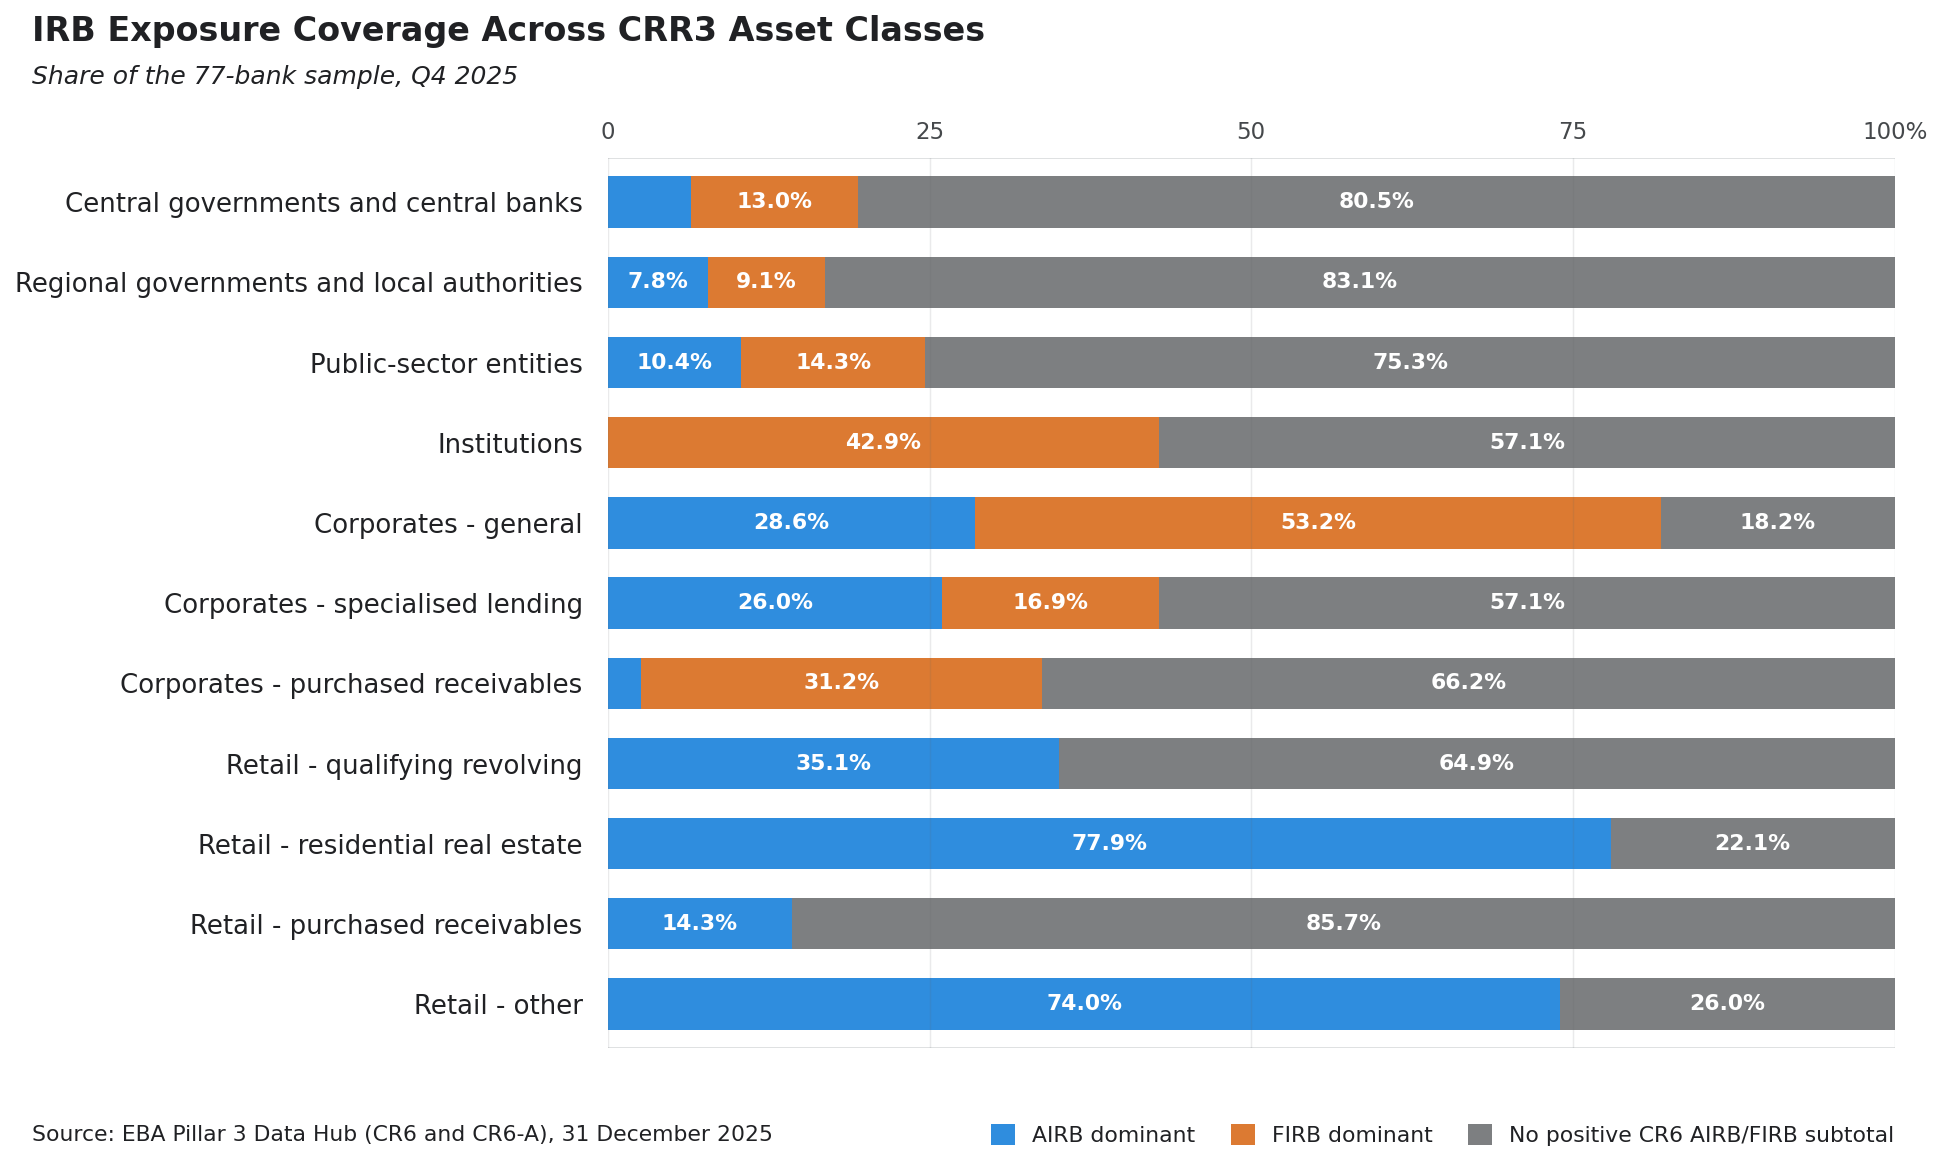

Saved coverage chart: C:\projects\irb_approaches\outputs\20260731_pillar3_group_irb_models\pillar3_irb_exposure_coverage_by_asset_class_2025q4.png


In [7]:
# 5.2 SQL summary and editorial coverage chart
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

coverage_by_asset_class = con.sql("""
WITH classified AS (
    SELECT
        class_order,
        asset_class,
        CASE
            WHEN airb_ead > firb_ead AND airb_ead > 0 THEN 'AIRB dominant'
            WHEN firb_ead > airb_ead AND firb_ead > 0 THEN 'FIRB dominant'
            ELSE 'No positive CR6 AIRB/FIRB subtotal'
        END AS coverage_bucket
    FROM bank_asset_class_inference
    WHERE class_order BETWEEN 1 AND 11
),
summarised AS (
    SELECT
        class_order,
        asset_class,
        count(*) AS sample_banks,
        count(*) FILTER (WHERE coverage_bucket = 'AIRB dominant') AS airb_dominant_banks,
        count(*) FILTER (WHERE coverage_bucket = 'FIRB dominant') AS firb_dominant_banks,
        count(*) FILTER (
            WHERE coverage_bucket = 'No positive CR6 AIRB/FIRB subtotal'
        ) AS no_resolved_af_banks
    FROM classified
    GROUP BY class_order, asset_class
)
SELECT
    class_order,
    asset_class,
    sample_banks,
    airb_dominant_banks,
    firb_dominant_banks,
    no_resolved_af_banks,
    100.0 * airb_dominant_banks / sample_banks AS airb_dominant_pct,
    100.0 * firb_dominant_banks / sample_banks AS firb_dominant_pct,
    100.0 * no_resolved_af_banks / sample_banks AS no_resolved_af_pct
FROM summarised
ORDER BY class_order
""").df()

assert coverage_by_asset_class["sample_banks"].eq(77).all()
assert (
    coverage_by_asset_class[
        ["airb_dominant_banks", "firb_dominant_banks", "no_resolved_af_banks"]
    ].sum(axis=1)
    == coverage_by_asset_class["sample_banks"]
).all()

plot_data = coverage_by_asset_class.copy()
plot_data["chart_label"] = plot_data["asset_class"].replace({
    "Regional governments and local authorities":
        "Regional governments and local authorities"
})
series = [
    ("airb_dominant_pct", "AIRB dominant", "#2F8DDE"),
    ("firb_dominant_pct", "FIRB dominant", "#DC7A32"),
    ("no_resolved_af_pct", "No positive CR6 AIRB/FIRB subtotal", "#7D7F81"),
]

fig = plt.figure(figsize=(13.0, 8.3), dpi=150, facecolor="white")
ax = fig.add_axes([0.315, 0.125, 0.66, 0.715])
ax.set_facecolor("white")

y_positions = list(range(len(plot_data)))
left = pd.Series(0.0, index=plot_data.index)

for column, label, color in series:
    values = plot_data[column]
    ax.barh(
        y_positions,
        values,
        left=left,
        height=0.64,
        color=color,
        edgecolor="none",
        label=label,
    )
    for y_pos, start, value in zip(y_positions, left, values):
        if value >= 7.5:
            ax.text(
                start + value / 2,
                y_pos,
                f"{value:.1f}%",
                ha="center",
                va="center",
                color="white",
                fontsize=10.5,
                fontweight="bold",
            )
    left = left + values

ax.set_xlim(0, 100)
ax.set_ylim(-0.55, len(plot_data) - 0.45)
ax.invert_yaxis()
ax.set_yticks(y_positions, labels=plot_data["chart_label"])
ax.set_xticks([0, 25, 50, 75, 100], labels=["0", "25", "50", "75", "100%"])
ax.xaxis.tick_top()
ax.tick_params(axis="x", colors="#45484B", labelsize=11, length=0, pad=7)
ax.tick_params(axis="y", colors="#202124", labelsize=12.5, length=0, pad=12)
for tick_label in ax.get_xticklabels():
    tick_label.set_fontweight("medium")
ax.grid(axis="x", color="#5F6368", alpha=0.13, linewidth=0.7)
ax.set_axisbelow(False)
for spine in ax.spines.values():
    spine.set_visible(False)

ax.axhline(-0.55, color="#D9DCDD", linewidth=0.8)
ax.axhline(len(plot_data) - 0.45, color="#D9DCDD", linewidth=0.8)

fig.text(
    0.02,
    0.955,
    "IRB Exposure Coverage Across CRR3 Asset Classes",
    ha="left",
    va="top",
    fontsize=16,
    color="#202124",
    fontweight="semibold",
)
fig.text(
    0.02,
    0.915,
    "Share of the 77-bank sample, Q4 2025",
    ha="left",
    va="top",
    fontsize=12,
    color="#202124",
    style="italic",
)

legend_handles = [Patch(facecolor=color, edgecolor="none", label=label) for _, label, color in series]
legend = fig.legend(
    handles=legend_handles,
    loc="center right",
    bbox_to_anchor=(0.985, 0.055),
    ncol=3,
    frameon=False,
    fontsize=10.5,
    handlelength=1.1,
    handleheight=1.1,
    columnspacing=1.6,
)
for legend_text in legend.get_texts():
    legend_text.set_color("#202124")
    legend_text.set_fontweight("medium")

fig.text(
    0.02,
    0.055,
    "Source: EBA Pillar 3 Data Hub (CR6 and CR6-A), 31 December 2025",
    ha="left",
    va="center",
    fontsize=10.5,
    color="#202124",
    fontweight="medium",
)

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
coverage_chart_path = OUTPUT_DIR / "pillar3_irb_exposure_coverage_by_asset_class_2025q4.png"
fig.savefig(coverage_chart_path, dpi=180, bbox_inches="tight", facecolor="white")
plt.show()

print(f"Saved coverage chart: {coverage_chart_path.resolve()}")


### 5.3 Detailed evidence by bank and asset class

This table shows every cell with positive IRB evidence, slotting exposure, an inapplicable
AIRB/FIRB distinction or a DQ exception. It retains the classification, evidence basis, AIRB and
FIRB CR6 subtotal EAD, the raw reported CR6-A current-IRB value, specialised-lending subrow signals,
exact positive CR6 members, reasoning and source-report links.


In [8]:
classification_detail = con.sql("""
SELECT
    country,
    bank,
    lei,
    class_order,
    asset_class,
    classification,
    evidence_basis,
    airb_share_of_resolved_irb_pct,
    airb_ead,
    firb_ead,
    unspecified_irb_ead,
    class_total_ead,
    cr6a_irb_share_reported,
    non_slotting_irb_share_reported,
    slotting_irb_share_reported,
    positive_member_evidence,
    key_repair_note,
    reasoning,
    cr6_source_link,
    cr6a_source_link
FROM bank_asset_class_inference
ORDER BY country, bank, lei, class_order
""").df()

# Display all classifications with positive or unresolved IRB evidence. The exported CSV contains
# every bank-class row, including "no evidence" and "not reported" cells.
irb_relevant = classification_detail.loc[
    ~classification_detail["classification"].isin([
        "No current IRB exposure",
        "No IRB exposure - SA under CRR3",
        "Not reported / not applicable",
    ])
]
display(irb_relevant)

,country,bank,lei,class_order,asset_class,classification,evidence_basis,airb_share_of_resolved_irb_pct,airb_ead,firb_ead,unspecified_irb_ead,class_total_ead,cr6a_irb_share_reported,non_slotting_irb_share_reported,slotting_irb_share_reported,positive_member_evidence,key_repair_note,reasoning,cr6_source_link,cr6a_source_link
3,Austria,Raiffeisen Bank International AG,9ZHRYM6F437SQJ6OUG95,4,Institutions,FIRB exposure,Direct CR6 AIRB/FIRB exposure,0.0,0.000000e+00,5.342320e+09,0.0,8.368278e+09,0.229644,NaN,NaN,Institutions without own estimates of LGD or c...,None,Positive CR6 subtotal EAD appears only in pres...,https://errp.eba.europa.eu/public-documents/CO...,https://errp.eba.europa.eu/public-documents/CO...
4,Austria,Raiffeisen Bank International AG,9ZHRYM6F437SQJ6OUG95,5,Corporates - general,FIRB exposure,Direct CR6 AIRB/FIRB exposure,0.0,0.000000e+00,3.846601e+10,0.0,NaN,NaN,NaN,NaN,Corporates - Other without own estimates of LG...,Hub dm_TableKey link missing; resolved from th...,Positive CR6 subtotal EAD appears only in pres...,https://errp.eba.europa.eu/public-documents/CO...,https://errp.eba.europa.eu/public-documents/CO...
5,Austria,Raiffeisen Bank International AG,9ZHRYM6F437SQJ6OUG95,6,Corporates - specialised lending,DQ exception - CR6-A IRB does not reconcile to...,CR6-A/CR6 reconciliation exception,NaN,0.000000e+00,0.000000e+00,0.0,NaN,NaN,0.963457,0.01507,None,None,The reported CR6-A/CR6 evidence conflicts with...,None,https://errp.eba.europa.eu/public-documents/CO...
6,Austria,Raiffeisen Bank International AG,9ZHRYM6F437SQJ6OUG95,7,Corporates - purchased receivables,FIRB exposure,Direct CR6 AIRB/FIRB exposure,0.0,0.000000e+00,1.007594e+09,0.0,NaN,NaN,NaN,NaN,Corporates - Purchased receivables without own...,None,Positive CR6 subtotal EAD appears only in pres...,https://errp.eba.europa.eu/public-documents/CO...,https://errp.eba.europa.eu/public-documents/CO...
7,Austria,Raiffeisen Bank International AG,9ZHRYM6F437SQJ6OUG95,8,Retail - qualifying revolving,AIRB exposure,Direct CR6 AIRB/FIRB exposure,100.0,1.472503e+09,0.000000e+00,0.0,1.533145e+09,0.000123,NaN,NaN,Retail - Qualifying revolving - with own estim...,None,Positive CR6 subtotal EAD appears only in own-...,https://errp.eba.europa.eu/public-documents/CO...,https://errp.eba.europa.eu/public-documents/CO...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1058,Sweden,Swedbank - Grupp,M312WZV08Y7LYUC71685,9,Retail - residential real estate,AIRB exposure,Direct CR6 AIRB/FIRB exposure,100.0,9.760190e+10,0.000000e+00,0.0,9.932135e+10,0.981800,NaN,NaN,Retail exposures - Secured by residential real...,None,Positive CR6 subtotal EAD appears only in own-...,https://errp.eba.europa.eu/public-documents/CO...,https://errp.eba.europa.eu/public-documents/CO...
1060,Sweden,Swedbank - Grupp,M312WZV08Y7LYUC71685,11,Retail - other,AIRB exposure,Direct CR6 AIRB/FIRB exposure,100.0,1.329187e+10,0.000000e+00,0.0,1.701539e+10,0.779200,NaN,NaN,Retail exposures - Other - with own estimates ...,None,Positive CR6 subtotal EAD appears only in own-...,https://errp.eba.europa.eu/public-documents/CO...,https://errp.eba.europa.eu/public-documents/CO...
1063,Sweden,Swedbank - Grupp,M312WZV08Y7LYUC71685,14,Other non-credit-obligation assets,IRB treatment - AIRB/FIRB not applicable,CR6/CR6-A IRB signal; AIRB/FIRB distinction no...,NaN,0.000000e+00,0.000000e+00,0.0,2.403364e+09,0.948100,NaN,NaN,None,None,"Current IRB treatment is reported, but this ex...",None,https://errp.eba.europa.eu/public-documents/CO...
1068,Sweden,Ziklo Bank AB,549300ZEF3QWM810M319,5,Corporates - general,FIRB exposure,Direct CR6 AIRB/FIRB exposure,0.0,0.000000e+00,1.469630e+09,0.0,1.550241e+09,NaN,NaN,NaN,Corporates - Other without own estimates of LG...,Hub dm_TableKey link missing; resolved from th...,Positive CR6 subtotal EAD appears only in pres...,https://errp.eba.europa.eu/public-documents/CO...,https://errp.eba.europa.eu/public-documents/CO...


## 6. Interpretation limits

- FIRB and AIRB both use own PD estimates; the distinction here is own versus prescribed LGD/CCF.
- Retail IRB is AIRB and institutions IRB is FIRB under the applicable CRR3 parameter rules.
- Supervisory slotting and the CIU/other-non-credit-obligation treatments are not forced into AIRB
  or FIRB.
- A DQ-exception cell is not assigned to AIRB or FIRB until CR6-A and CR6 are reconciled to the
  source filing.
- Later resubmissions can change the current report instance, so instance identifiers and source
  links are retained.


In [9]:
# 7. Export complete audit-ready results and raw query snapshots
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

long_path = OUTPUT_DIR / "pillar3_group_irb_model_inference_2025q4_long.csv"
matrix_path = OUTPUT_DIR / "pillar3_group_irb_model_inference_2025q4_matrix.csv"
cr6_raw_path = OUTPUT_DIR / "pillar3_cr6_subtotal_ead_raw_2025q4.csv"
cr6a_raw_path = OUTPUT_DIR / "pillar3_cr6a_raw_2025q4.csv"
metadata_path = OUTPUT_DIR / "pillar3_group_irb_model_inference_2025q4_metadata.json"

classification_detail.to_csv(long_path, index=False)
matrix.to_csv(matrix_path, index=False)
cr6_raw_export = con.sql("""
SELECT * REPLACE (
    lpad(CAST(row_code AS VARCHAR), 4, '0') AS row_code,
    lpad(CAST(column_code AS VARCHAR), 4, '0') AS column_code
) FROM p3_cr6_raw
""").df()
cr6a_raw_export = con.sql("""
SELECT * REPLACE (
    lpad(CAST(row_code AS VARCHAR), 4, '0') AS row_code,
    lpad(CAST(column_code AS VARCHAR), 4, '0') AS column_code
)
FROM p3_cr6a_raw
WHERE lpad(CAST(column_code AS VARCHAR), 4, '0') IN ('0020', '0040')
""").df()
assert cr6_raw_export['row_code'].astype(str).str.fullmatch(r'\d{4}').all()
assert cr6a_raw_export['row_code'].astype(str).str.fullmatch(r'\d{4}').all()
cr6_raw_export.to_csv(cr6_raw_path, index=False)
cr6a_raw_export.to_csv(cr6a_raw_path, index=False)

metadata = {
    "reference_date": str(REFERENCE_DATE.date()),
    "extracted_at_utc": EXTRACTED_AT_UTC.isoformat(),
    "population": (
        "Current accepted Large highest EEA and Other highest EEA institutions "
        "with positive CR6-A total EAD at 2025-12-31"
    ),
    "bank_count": int(len(matrix)),
    "asset_class_count": int(con.sql("SELECT count(*) FROM asset_class_map").fetchone()[0]),
    "classification_row_count": int(len(classification_detail)),
    "cr6_table_vid": CR6_TABLE_VID,
    "cr6a_table_vid": CR6A_TABLE_VID,
    "reference_document": "pillar3_hub_data_model_reference_20260730T224432.md",
    "key_fallback": {
        "unique_key_id": "161333573377302602",
        "dpm_member": "eba_qAE:qx2012",
        "meaning": "Corporates - Other without own estimates of LGD or conversion factors",
    },
}
metadata_path.write_text(json.dumps(metadata, indent=2), encoding="utf-8")

print("Created:")
for path in [long_path, matrix_path, cr6_raw_path, cr6a_raw_path, metadata_path]:
    print(f" - {path.resolve()}")

Created:
 - C:\projects\irb_approaches\outputs\20260731_pillar3_group_irb_models\pillar3_group_irb_model_inference_2025q4_long.csv
 - C:\projects\irb_approaches\outputs\20260731_pillar3_group_irb_models\pillar3_group_irb_model_inference_2025q4_matrix.csv
 - C:\projects\irb_approaches\outputs\20260731_pillar3_group_irb_models\pillar3_cr6_subtotal_ead_raw_2025q4.csv
 - C:\projects\irb_approaches\outputs\20260731_pillar3_group_irb_models\pillar3_cr6a_raw_2025q4.csv
 - C:\projects\irb_approaches\outputs\20260731_pillar3_group_irb_models\pillar3_group_irb_model_inference_2025q4_metadata.json
